# Task 2: sensibilidad al supuesto del buffer circular

## Preparación: carga de datos (replica del pipeline del Task 1)

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import unary_union

carpeta_datos = Path("datos")
crs_proyectado = "EPSG:32613"   # UTM 13N, mismo CRS del Task 1 (distancias en metros)
fips_estado = "08"              # Colorado

hospitales = gpd.read_file(carpeta_datos / "hospitales_eeuu.geojson")
condados = gpd.read_file(carpeta_datos / "condados_eeuu.geojson")
poblacion = pd.read_csv(carpeta_datos / "poblacion_condados.csv")

# Hospitales de Colorado con dato de camas (limpieza del Task 1.1b)
hospitales_m = (
    hospitales.loc[(hospitales["estado"] == "CO") & hospitales["camas_total"].notna()]
    .to_crs(crs_proyectado)
    .reset_index(drop=True)
)

# Población: FIPS a 5 dígitos y sin territorios (FIPS >= 80000)
fips_num = pd.to_numeric(poblacion["fips"], errors="raise")
poblacion = poblacion.loc[fips_num < 80000, ["fips", "poblacion"]].copy()
poblacion["fips"] = pd.to_numeric(poblacion["fips"]).astype(int).astype(str).str.zfill(5)

condados["fips"] = pd.to_numeric(condados["fips"]).astype(int).astype(str).str.zfill(5)
condados["cod_estado"] = pd.to_numeric(condados["cod_estado"]).astype(int).astype(str).str.zfill(2)

condados_m = (
    condados.loc[condados["cod_estado"] == fips_estado]
    .merge(poblacion, on="fips", how="left", validate="one_to_one")
    .to_crs(crs_proyectado)
    .reset_index(drop=True)
)

assert condados_m["poblacion"].notna().all()
print(f"Hospitales: {len(hospitales_m)} | Condados: {len(condados_m)} | "
      f"Población total: {condados_m['poblacion'].sum():,.0f}")

Hospitales: 99 | Condados: 64 | Población total: 5,758,736


## Task 2.1(a): distancia del centroide de cada condado al hospital más cercano

In [2]:
# Distancia euclidiana en el plano proyectado (metros): d = sqrt((x1-x2)^2 + (y1-y2)^2).
# Punto de referencia de cada condado: su centroide. Se toma el mínimo sobre todos los hospitales.
centroides = condados_m.geometry.centroid

def hospital_mas_cercano(punto):
    distancias = hospitales_m.distance(punto)          # metros, a los 99 hospitales
    return pd.Series({
        "idx_hospital": distancias.idxmin(),
        "distancia_km": distancias.min() / 1000,
    })

cercano = centroides.apply(hospital_mas_cercano)
condados_m["idx_hospital"] = cercano["idx_hospital"].astype(int)
condados_m["distancia_km"] = cercano["distancia_km"]

top10_distancia = (
    condados_m.sort_values("distancia_km", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_distancia.index += 1

display(top10_distancia[["nombre", "poblacion", "distancia_km"]].round(2))
print(f"Distancia mediana estatal (centroide a hospital): {condados_m['distancia_km'].median():.1f} km")

,nombre,poblacion,distancia_km
1,San Miguel,8179.0,70.81
2,Hinsdale,820.0,65.96
3,Elbert,26729.0,59.46
4,San Juan,728.0,59.29
5,Moffat,13283.0,54.36
6,Park,18845.0,52.35
7,Rio Blanco,6324.0,51.71
8,Mineral,769.0,48.64
9,Jackson,1392.0,46.05
10,Saguache,6824.0,45.89


Distancia mediana estatal (centroide a hospital): 20.8 km


## Task 2.1(b): curva de cobertura acumulada (5 a 100 km)

In [3]:
# Mismo método del Task 1.3(b):
#   fraccion_i(r) = Area(condado_i ∩ U_r) / Area(condado_i),  U_r = unary_union de los buffers de radio r
#   Cobertura(r)  = sum_i poblacion_i * fraccion_i(r) / sum_i poblacion_i
# (supone población uniforme dentro de cada condado)
radios_km = np.arange(5, 101, 5)
poblacion_total = condados_m["poblacion"].sum()
areas = condados_m.geometry.area

cobertura_pct = []
for r in radios_km:
    union_r = unary_union([g.buffer(r * 1000, quad_segs=32) for g in hospitales_m.geometry])
    fraccion = (condados_m.geometry.intersection(union_r).area / areas).clip(0, 1)
    cobertura_pct.append((condados_m["poblacion"] * fraccion).sum() / poblacion_total * 100)

curva = pd.DataFrame({"radio_km": radios_km, "cobertura_pct": cobertura_pct})
curva["ganancia_pp"] = curva["cobertura_pct"].diff()   # puntos porcentuales ganados al pasar al radio siguiente (5 km)

display(curva.round(2))

,radio_km,cobertura_pct,ganancia_pp
0,5,14.39,NaN
1,10,26.82,12.43
2,15,37.83,11.01
3,20,48.44,10.61
4,25,57.87,9.43
5,30,65.44,7.58
6,35,72.32,6.87
7,40,78.45,6.13
8,45,83.59,5.14
9,50,87.97,4.38


Rodilla (Kneedle): 45 km -> 83.6% de cobertura
Ganancia marginal < 5 pp por 5 km: a partir de 50 km -> 88.0%


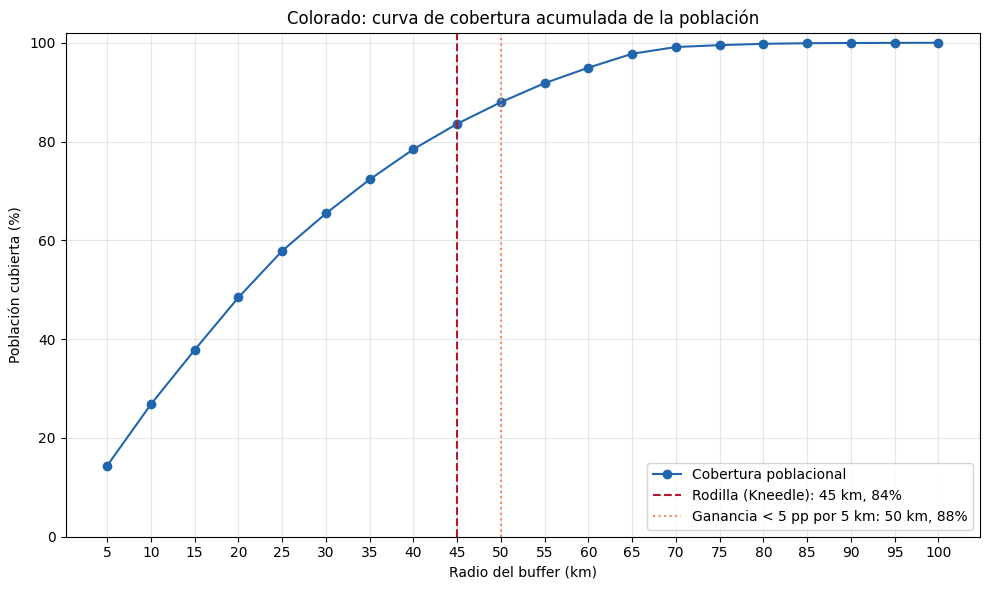

In [4]:
# Punto de inflexión / "rodilla" de la curva con dos criterios:
# 1) Kneedle: normalizar ambos ejes a [0,1] y tomar el punto de máxima distancia sobre la diagonal, max(y - x).
x_n = (curva["radio_km"] - curva["radio_km"].min()) / (curva["radio_km"].max() - curva["radio_km"].min())
y_n = (curva["cobertura_pct"] - curva["cobertura_pct"].min()) / (curva["cobertura_pct"].max() - curva["cobertura_pct"].min())
radio_rodilla = int(curva.loc[(y_n - x_n).idxmax(), "radio_km"])
cob_rodilla = float(curva.loc[curva["radio_km"] == radio_rodilla, "cobertura_pct"].iloc[0])

# 2) Ganancia marginal: primer radio en que agrandar 5 km suma menos de 5 puntos porcentuales (< 1 pp/km).
radio_marginal = int(curva.loc[curva["ganancia_pp"] < 5, "radio_km"].iloc[0])
cob_marginal = float(curva.loc[curva["radio_km"] == radio_marginal, "cobertura_pct"].iloc[0])

print(f"Rodilla (Kneedle): {radio_rodilla} km -> {cob_rodilla:.1f}% de cobertura")
print(f"Ganancia marginal < 5 pp por 5 km: a partir de {radio_marginal} km -> {cob_marginal:.1f}%")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(curva["radio_km"], curva["cobertura_pct"], marker="o", color="#2166ac", label="Cobertura poblacional")
ax.axvline(radio_rodilla, color="#b2182b", linestyle="--", label=f"Rodilla (Kneedle): {radio_rodilla} km, {cob_rodilla:.0f}%")
ax.axvline(radio_marginal, color="#ef8a62", linestyle=":", label=f"Ganancia < 5 pp por 5 km: {radio_marginal} km, {cob_marginal:.0f}%")
ax.set_xlabel("Radio del buffer (km)")
ax.set_ylabel("Población cubierta (%)")
ax.set_title("Colorado: curva de cobertura acumulada de la población")
ax.set_xticks(radios_km)
ax.set_ylim(0, 102)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Task 2.1(c): tipo y camas del hospital más cercano a los cinco condados más alejados

In [5]:
top5 = top10_distancia.head(5)
cercanos = hospitales_m.loc[top5["idx_hospital"], ["nombre", "tipo", "camas_total", "condado"]].reset_index(drop=True)
cercanos.columns = ["hospital_mas_cercano", "tipo", "camas_total", "condado_del_hospital"]

tabla_2_1c = pd.concat(
    [top5[["nombre", "distancia_km"]].reset_index(drop=True), cercanos], axis=1
).rename(columns={"nombre": "condado"})
tabla_2_1c.index += 1
display(tabla_2_1c.round(1))

# Referencia: los 99 hospitales de Colorado
print(f"Camas de los 5 hospitales: media {tabla_2_1c['camas_total'].mean():.1f}, mediana {tabla_2_1c['camas_total'].median():.0f}")
print(f"Camas de todos los hospitales: media {hospitales_m['camas_total'].mean():.1f}, mediana {hospitales_m['camas_total'].median():.0f}")

tipos_ref = hospitales_m["tipo"].value_counts(normalize=True).mul(100).round(1).rename("% de los 99 hospitales")
tipos_top5 = tabla_2_1c["tipo"].value_counts().rename("hospitales entre los 5")
display(pd.concat([tipos_top5, tipos_ref], axis=1).fillna(0))

,condado,distancia_km,hospital_mas_cercano,tipo,camas_total,condado_del_hospital
1,San Miguel,70.8,MONTROSE MEMORIAL HOSPITAL,GENERAL ACUTE CARE,50.0,MONTROSE
2,Hinsdale,66.0,PAGOSA MOUNTAIN HOSPITAL,CRITICAL ACCESS,11.0,ARCHULETA
3,Elbert,59.5,LINCOLN COMMUNITY HOSPITAL,CRITICAL ACCESS,15.0,LINCOLN
4,San Juan,59.3,"ANIMAS SURGICAL HOSPITAL, LLC",GENERAL ACUTE CARE,12.0,LA PLATA
5,Moffat,54.4,"MEMORIAL HOSPITAL, THE",CRITICAL ACCESS,25.0,MOFFAT


Camas de los 5 hospitales: media 22.6, mediana 15
Camas de todos los hospitales: media 103.0, mediana 48


,hospitales entre los 5,% de los 99 hospitales
tipo,,
CRITICAL ACCESS,3.0,27.3
GENERAL ACUTE CARE,2.0,50.5
PSYCHIATRIC,0.0,8.1
REHABILITATION,0.0,5.1
LONG TERM CARE,0.0,5.1
CHILDREN,0.0,2.0
MILITARY,0.0,1.0
SPECIAL,0.0,1.0


# Task 2.2: índice compuesto de vulnerabilidad de acceso hospitalario

## Task 2.2(a): componentes y normalización min-max

In [6]:
# --- Componente 1: distancia (km) del centroide al hospital más cercano (calculada en 2.1a) ---
condados_m["c1_bruto"] = condados_m["distancia_km"]

# --- Componente 2: inverso de las camas por habitante = habitantes por cama ---
# camas_per_capita = camas / poblacion   ->   inverso = poblacion / camas
hospitales_m["fips_condado"] = (
    pd.to_numeric(hospitales_m["fips_condado"]).astype(int).astype(str).str.zfill(5)
)
camas_condado = hospitales_m.groupby("fips_condado")["camas_total"].sum()
condados_m["camas_totales"] = condados_m["fips"].map(camas_condado).fillna(0)

habitantes_por_cama = condados_m["poblacion"] / condados_m["camas_totales"].where(condados_m["camas_totales"] > 0)
sin_camas = habitantes_por_cama.isna()
# Condados sin hospitales: se asigna el valor máximo observado ANTES de normalizar
condados_m["c2_bruto"] = habitantes_por_cama.fillna(habitantes_por_cama.max())

# --- Componente 3: ocupación promedio (fracción 0-1) de los hospitales a <= 50 km del centroide ---
def ocupacion_50km(punto):
    cerca = hospitales_m.loc[hospitales_m.distance(punto) <= 50_000, "ocupacion_total"]
    return cerca.mean() if cerca.notna().any() else np.nan   # NaN si no hay hospital (o ninguno con dato)

c3 = centroides.apply(ocupacion_50km)
sin_hosp_50km = c3.isna()
# Condados sin hospitales a 50 km: valor máximo observado antes de normalizar
condados_m["c3_bruto"] = c3.fillna(c3.max())

# --- Normalización min-max:  x' = (x - min) / (max - min)  en [0, 1] ---
def minmax(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

condados_m["c1"] = minmax(condados_m["c1_bruto"])
condados_m["c2"] = minmax(condados_m["c2_bruto"])
condados_m["c3"] = minmax(condados_m["c3_bruto"])

print(f"Condados sin camas (c2 = máximo): {int(sin_camas.sum())}")
print(f"Condados sin hospital con dato de ocupación a 50 km (c3 = máximo): {int(sin_hosp_50km.sum())}")
print(f"Máximo bruto c2: {condados_m['c2_bruto'].max():,.0f} hab/cama | máximo bruto c3: {condados_m['c3_bruto'].max():.2f}")

resumen = condados_m[["c1_bruto", "c2_bruto", "c3_bruto", "c1", "c2", "c3"]].describe().loc[["min", "50%", "mean", "max"]]
display(resumen.round(3))
print("Asimetría de los componentes normalizados:")
display(condados_m[["c1", "c2", "c3"]].skew().round(2).to_frame("asimetría").T)

display(
    condados_m[["nombre", "poblacion", "c1_bruto", "c2_bruto", "c3_bruto", "c1", "c2", "c3"]]
    .sort_values("nombre").head(10).round(3)
)

Condados sin camas (c2 = máximo): 17
Condados sin hospital con dato de ocupación a 50 km (c3 = máximo): 9
Máximo bruto c2: 2,491 hab/cama | máximo bruto c3: 0.73


,c1_bruto,c2_bruto,c3_bruto,c1,c2,c3
min,1.195,56.240,0.130,0.000,0.000,0.000
50%,20.807,757.581,0.420,0.282,0.288,0.487
mean,26.179,1169.268,0.453,0.359,0.457,0.542
max,70.814,2490.944,0.726,1.000,1.000,1.000


Asimetría de los componentes normalizados:


,c1,c2,c3
asimetría,0.59,0.63,0.11


,nombre,poblacion,c1_bruto,c2_bruto,c3_bruto,c1,c2,c3
16,Adams,517421.0,38.108,384.128,0.630,0.530,0.135,0.839
0,Alamosa,16233.0,14.086,331.286,0.290,0.185,0.113,0.268
53,Arapahoe,656590.0,39.018,618.258,0.646,0.543,0.231,0.866
17,Archuleta,14029.0,6.765,1275.364,0.290,0.080,0.501,0.268
18,Baca,3581.0,10.486,238.733,0.320,0.133,0.075,0.319
41,Bent,5577.0,41.908,2490.944,0.350,0.585,1.000,0.369
1,Boulder,326196.0,13.061,490.520,0.526,0.170,0.178,0.664
2,Broomfield,70465.0,3.899,765.924,0.579,0.039,0.291,0.754
19,Chaffee,20356.0,28.138,814.240,0.420,0.387,0.311,0.487
20,Cheyenne,1831.0,21.737,166.455,0.350,0.295,0.045,0.369


## Task 2.2(b): pesos y cálculo del índice

In [7]:
# Índice = w1*c1 + w2*c2 + w3*c3, con w1 + w2 + w3 = 1 (promedio ponderado)
pesos = {"c1": 0.40, "c2": 0.35, "c3": 0.25}
assert abs(sum(pesos.values()) - 1) < 1e-12

condados_m["indice"] = sum(w * condados_m[c] for c, w in pesos.items())

top10_indice = condados_m.sort_values("indice", ascending=False).head(10).reset_index(drop=True)
top10_indice.index += 1
display(top10_indice[["nombre", "poblacion", "distancia_km", "camas_totales", "c1", "c2", "c3", "indice"]].round(3))

,nombre,poblacion,distancia_km,camas_totales,c1,c2,c3,indice
1,San Miguel,8179.0,70.814,0.0,1.000,1.0,1.000,1.000
2,Hinsdale,820.0,65.959,0.0,0.930,1.0,1.000,0.972
3,Elbert,26729.0,59.462,0.0,0.837,1.0,1.000,0.935
4,San Juan,728.0,59.289,0.0,0.834,1.0,1.000,0.934
5,Park,18845.0,52.349,0.0,0.735,1.0,1.000,0.894
6,Crowley,6061.0,43.647,0.0,0.610,1.0,1.000,0.844
7,Custer,5068.0,40.109,0.0,0.559,1.0,0.856,0.787
8,Saguache,6824.0,45.887,0.0,0.642,1.0,0.436,0.716
9,Dolores,2055.0,43.522,0.0,0.608,1.0,0.487,0.715
10,Mineral,769.0,48.644,0.0,0.682,1.0,0.352,0.711


## Task 2.2(c): mapa coroplético por quintiles

,min,max,count
categoria,,,
Muy baja,0.079,0.225,13
Baja,0.225,0.306,13
Media,0.317,0.404,12
Alta,0.438,0.673,13
Muy alta,0.676,1.000,13


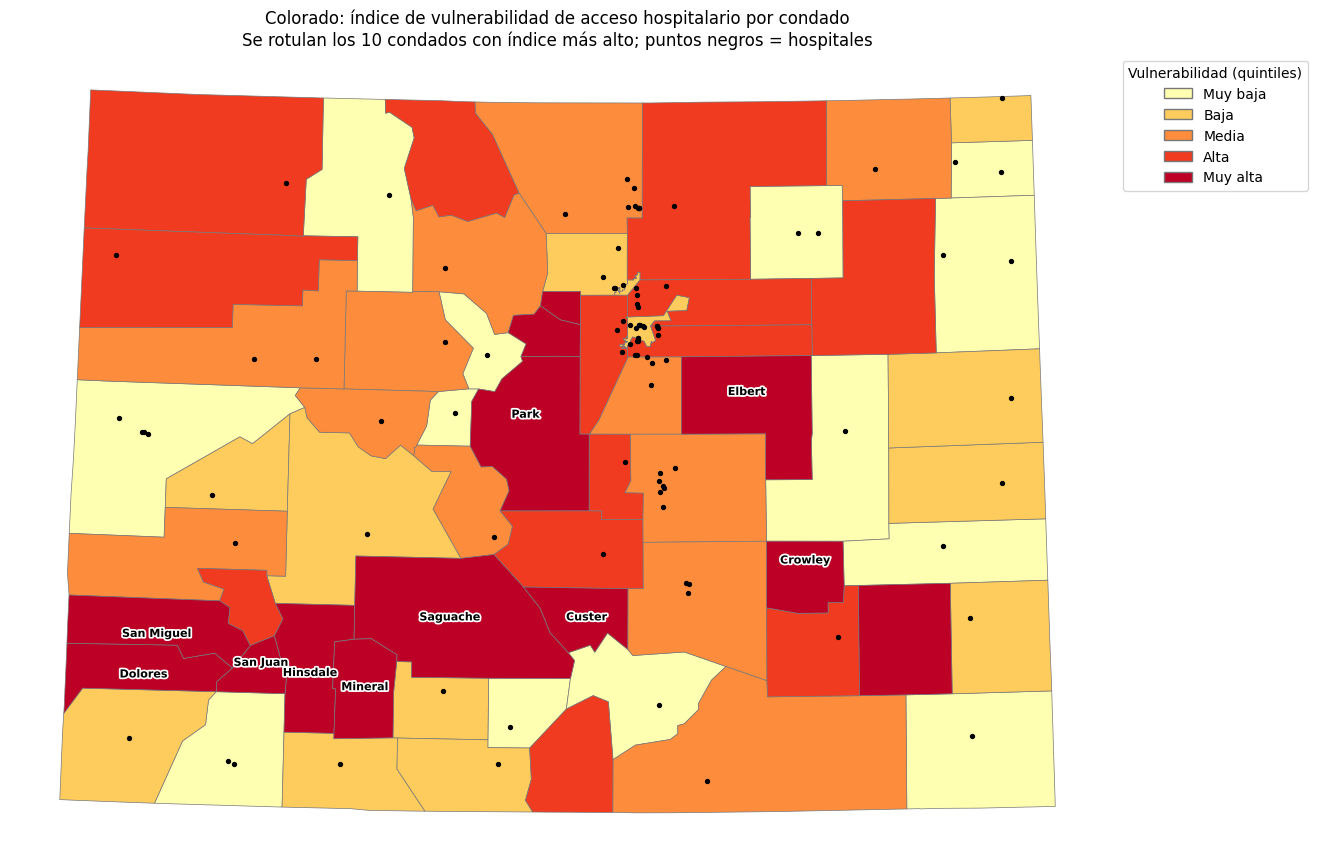

In [8]:
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

etiquetas_q = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
# rank(method="first") evita que los empates colapsen quintiles: 64 condados -> grupos de 13/13/12/13/13
condados_m["categoria"] = pd.qcut(condados_m["indice"].rank(method="first"), 5, labels=etiquetas_q)
colores_q = dict(zip(etiquetas_q, ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]))

limites = condados_m.groupby("categoria", observed=True)["indice"].agg(["min", "max", "count"]).round(3)
display(limites)

fig, ax = plt.subplots(figsize=(13, 9))
for cat in etiquetas_q:
    condados_m.loc[condados_m["categoria"] == cat].plot(
        ax=ax, facecolor=colores_q[cat], edgecolor="#777777", linewidth=0.5)

hospitales_m.plot(ax=ax, color="black", markersize=8, zorder=3)

# Diez condados con índice más alto: nombre sobre un punto representativo del condado
for _, fila in condados_m.sort_values("indice", ascending=False).head(10).iterrows():
    p = fila.geometry.representative_point()
    ax.annotate(fila["nombre"], (p.x, p.y), ha="center", fontsize=8, fontweight="bold", zorder=5,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

leyenda = [Patch(facecolor=colores_q[c], edgecolor="#777777", label=c) for c in etiquetas_q]
ax.legend(handles=leyenda, title="Vulnerabilidad (quintiles)", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("Colorado: índice de vulnerabilidad de acceso hospitalario por condado\n"
             "Se rotulan los 10 condados con índice más alto; puntos negros = hospitales")
ax.set_aspect("equal")
ax.set_axis_off()
plt.tight_layout()
plt.show()